# From Risk Prediction to Decision Support



## Taiwanese Bankruptcy Prediction



**Chapter 2 — Interpretable Models: Risk Scores, Calibration, and Recourse**



**Guiding question:** Can we turn a complex bankruptcy-prediction problem into a simple risk score that people can understand, interpret as probability, and use responsibly?



**Decision setting:** A corporate risk analyst uses the model as an **early-warning screening tool** to identify companies that may deserve deeper review. The model is not treated as an automated bankruptcy determination.



**Dataset:** UCI Machine Learning Repository — *Taiwanese Bankruptcy Prediction* (6,819 observations; financial indicators; bankruptcy target).


## 1. The Decision Problem

A financial analyst wants to identify companies that may be at elevated risk of bankruptcy.

The available dataset contains many financial indicators, but a useful decision tool should do more than produce an accurate prediction. It should also help us understand **why risk is high, how the score should be interpreted, and what conclusions we can responsibly draw from it**.

In this case, we will investigate three questions:

1. **Can we replace a large set of financial indicators with a small, understandable risk score?**
2. **Does a good ranking model also produce trustworthy probabilities?**
3. **If changing a feature changes the prediction, does that automatically make the change a valid real-world action?**

### What to pay attention to

- Bankruptcy is a **rare event**, so accuracy alone can be misleading.
- Simpler models may sacrifice some predictive performance in exchange for transparency.
- **Discrimination** and **calibration** answer different questions.
- A model-level counterfactual is not automatically a causal or feasible recommendation.


## 2. Understand the Data



Before building a risk score, we need to understand the structure of the prediction problem.



For this case, the most important questions are:



- How rare is bankruptcy?

- How many financial indicators are available?

- Are there missing or duplicated observations?

- Do many variables appear to represent similar financial information?



We keep the EDA focused on questions that affect **interpretability and model design**.



> **Data note:** Several indicators in this dataset use dataset-specific normalized or encoded scales. Thresholds learned later should therefore be interpreted as model thresholds for this dataset, **not universal accounting cutoffs**.


In [2]:
import pandas as pd
import numpy as np

DATA_PATH = '../Data/processed/taiwanese_bankruptcy_course.csv'
data = pd.read_csv(DATA_PATH)

print('Shape:', data.shape)
print('Missing values:', data.isna().sum().sum())
print('Duplicate rows:', data.duplicated().sum())
print('\nTarget distribution:')
print(data['Bankrupt?'].value_counts())
print('\nBankruptcy rate:', f"{data['Bankrupt?'].mean():.2%}")


Shape: (6819, 95)
Missing values: 0
Duplicate rows: 0

Target distribution:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Bankruptcy rate: 3.23%


### First observation

Bankruptcy is highly imbalanced: only about **3% of companies** belong to the bankruptcy class.

This immediately affects how we evaluate the model. A classifier that predicts every company as non-bankrupt would achieve very high accuracy while identifying **none of the bankrupt companies**.

So throughout this case, we will pay more attention to measures such as **ROC-AUC, precision-recall performance, and probability calibration** rather than relying on accuracy alone.


## 3. Protect the Test Set

Before using the target to compare or select financial indicators, we separate an untouched test set.

Because bankruptcy is rare, we use a **stratified split** so both sets preserve approximately the same bankruptcy rate.

> The dataset does not provide a usable company identifier or observation date for constructing a company-level or chronological evaluation split. Therefore, this notebook uses a stratified random holdout. The results should be interpreted as performance on held-out observations, **not as a temporal forecasting evaluation**.


In [3]:
from sklearn.model_selection import train_test_split

development_data, test_data = train_test_split(
    data,
    test_size=0.20,
    stratify=data['Bankrupt?'],
    random_state=42
)

print('Development set:', development_data.shape)
print('Test set:', test_data.shape)
print('\nBankrupt cases')
print('Development:', int(development_data['Bankrupt?'].sum()))
print('Test:', int(test_data['Bankrupt?'].sum()))
print('\nBankruptcy rates')
print('Development:', f"{development_data['Bankrupt?'].mean():.2%}")
print('Test:', f"{test_data['Bankrupt?'].mean():.2%}")


Development set: (5455, 95)
Test set: (1364, 95)

Bankrupt cases
Development: 176
Test: 44

Bankruptcy rates
Development: 3.23%
Test: 3.23%


From this point onward, decisions about feature selection, score construction, and model design will use the **development set only**. The test set stays untouched until the final evaluation.


## 4. Many Indicators, Repeated Information

The dataset contains many financial indicators. A tempting strategy would be to simply select the variables with the strongest relationship to bankruptcy.

But an interpretable scorecard should not repeat the same financial concept several times under slightly different variable names.

We first inspect which variables are most associated with bankruptcy, and then check whether those variables are strongly correlated with one another.


In [4]:
target_corr = (
    development_data.corr(numeric_only=True)['Bankrupt?']
    .drop('Bankrupt?')
    .sort_values(key=abs, ascending=False)
)

print('Top variables associated with bankruptcy:\n')
print(target_corr.head(15).round(3).to_string())


Top variables associated with bankruptcy:

Net Income to Total Assets                                -0.316
ROA(A) before interest and % after tax                    -0.284
ROA(B) before interest and depreciation after tax         -0.275
ROA(C) before interest and depreciation before interest   -0.263
Net worth/Assets                                          -0.248
Debt ratio %                                               0.248
Persistent EPS in the Last Four Seasons                   -0.221
Retained Earnings to Total Assets                         -0.214
Net Income to Stockholder's Equity                        -0.207
Net profit before tax/Paid-in capital                     -0.206
Per Share Net profit before tax (Yuan ¥)                  -0.205
Borrowing dependency                                       0.197
Current Liability to Assets                                0.190
Working Capital to Total Assets                           -0.188
Current Liability to Current Assets            

### Are the strongest variables really different signals?

Next, we examine correlations among the strongest candidate predictors. Very high correlations suggest that several variables may be carrying nearly the same information.


In [5]:
top_features = target_corr.head(20).index
top_corr = development_data[top_features].corr()

mask = np.triu(np.ones(top_corr.shape, dtype=bool), k=1)

pairs = (
    top_corr.where(mask)
    .stack()
    .sort_values(key=abs, ascending=False)
)

print('Strongest relationships among the top predictors:\n')
print(pairs.head(12).round(3).to_string())


Strongest relationships among the top predictors:

Current Liabilities/Equity                         Current Liability to Equity                                1.000
Net worth/Assets                                   Debt ratio %                                              -1.000
Net Value Per Share (A)                            Net Value Per Share (B)                                    1.000
ROA(B) before interest and depreciation after tax  ROA(C) before interest and depreciation before interest    0.987
Net profit before tax/Paid-in capital              Per Share Net profit before tax (Yuan ¥)                   0.986
Persistent EPS in the Last Four Seasons            Net profit before tax/Paid-in capital                      0.980
                                                   Per Share Net profit before tax (Yuan ¥)                   0.972
Liability to Equity                                Current Liabilities/Equity                                 0.967
                     

### What should we notice?

Some highly predictive variables are also highly correlated with one another. This creates an important interpretability problem:

> Selecting the strongest individual predictors can produce a scorecard that counts the **same underlying financial condition multiple times**.

Instead of selecting variables by predictive strength alone, we will look for a small set that represents **distinct financial concepts**.


## 5. From Many Variables to Three Financial Concepts



To keep the model understandable, we select one representative variable from three different financial dimensions:



- **Profitability:** `Net Income to Total Assets`

- **Leverage:** `Debt ratio %`

- **Working-capital position:** `Working Capital to Total Assets`



These variables are not chosen simply because they have the highest correlations with bankruptcy. They combine:



1. a meaningful relationship with the target,

2. distinct financial interpretations, and

3. less redundancy than selecting several variables from the same cluster.



Before fitting a model, we check whether observed bankruptcy risk changes in a sensible direction across each variable.



> **Think before running:** Which direction should indicate higher risk for each variable?


In [6]:
selected_features = [
    'Net Income to Total Assets',
    'Debt ratio %',
    'Working Capital to Total Assets',
]

for feature in selected_features:
    temp = development_data[[feature, 'Bankrupt?']].copy()
    temp['bin'] = pd.qcut(temp[feature], q=5, duplicates='drop')

    risk = (
        temp.groupby('bin', observed=True)['Bankrupt?']
        .agg(['count', 'mean'])
    )

    risk['bankruptcy_rate_%'] = risk['mean'] * 100

    print(f'\n--- {feature} ---')
    print(risk[['count', 'bankruptcy_rate_%']].round(2).to_string())



--- Net Income to Total Assets ---
                 count  bankruptcy_rate_%
bin                                      
(-0.001, 0.791]   1091              12.10
(0.791, 0.805]    1091               2.84
(0.805, 0.816]    1091               1.01
(0.816, 0.831]    1091               0.18
(0.831, 1.0]      1091               0.00

--- Debt ratio % ---
                  count  bankruptcy_rate_%
bin                                       
(-0.001, 0.0641]   1091               0.18
(0.0641, 0.0973]   1091               0.46
(0.0973, 0.125]    1091               1.19
(0.125, 0.158]     1091               1.83
(0.158, 1.0]       1091              12.47

--- Working Capital to Total Assets ---
                 count  bankruptcy_rate_%
bin                                      
(-0.001, 0.765]   1091               9.35
(0.765, 0.795]    1091               3.12
(0.795, 0.825]    1091               1.83
(0.825, 0.861]    1091               1.10
(0.861, 1.0]      1091               0.73


### Interpretation

For a scorecard, we prefer variables where risk changes in a reasonably consistent direction:

- lower profitability should generally correspond to higher observed risk,
- higher leverage should generally correspond to higher observed risk,
- lower working capital should generally correspond to higher observed risk.

The relationship does not need to be perfectly monotonic. Bankruptcy is rare, so some variation between neighboring bins is expected.

> These bins are used for **exploration only**. We have not yet decided the final scorecard thresholds or point values.


## 6. How Much Performance Do We Lose by Staying Simple?



Interpretability involves a trade-off. A smaller model is easier to understand, but simplicity is only useful if predictive performance remains reasonable.



We compare:



- a **3-feature model** representing profitability, leverage, and working-capital position;

- a **7-feature model** that adds several additional financial indicators.



Because bankruptcy is rare, we evaluate both **ROC-AUC** and **PR-AUC** using stratified cross-validation on the development set.



- ROC-AUC summarizes discrimination across thresholds.

- PR-AUC is especially informative here because the positive class is rare and we care about retrieving bankrupt companies without overwhelming false positives.



> **Before revealing the result:** Do you expect four additional financial indicators to produce a large improvement, a small improvement, or almost none?



> The held-out test set is still untouched.


In [7]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

small_features = [
    'Net Income to Total Assets',
    'Debt ratio %',
    'Working Capital to Total Assets',
]

larger_features = [
    'Net Income to Total Assets',
    'Debt ratio %',
    'Persistent EPS in the Last Four Seasons',
    'Retained Earnings to Total Assets',
    'Current Liability to Assets',
    'Working Capital to Total Assets',
    'Current Liability to Current Assets',
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

comparison = {}

for name, features in {
    '3-feature model': small_features,
    '7-feature model': larger_features,
}.items():
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000)
    )

    scores = cross_validate(
        model,
        development_data[features],
        development_data['Bankrupt?'],
        cv=cv,
        scoring={
            'roc_auc': 'roc_auc',
            'pr_auc': 'average_precision',
        }
    )

    comparison[name] = {
        'ROC-AUC mean': scores['test_roc_auc'].mean(),
        'ROC-AUC std': scores['test_roc_auc'].std(),
        'PR-AUC mean': scores['test_pr_auc'].mean(),
        'PR-AUC std': scores['test_pr_auc'].std(),
    }

comparison_df = pd.DataFrame(comparison).T
comparison_df.round(3)


,ROC-AUC mean,ROC-AUC std,PR-AUC mean,PR-AUC std
3-feature model,0.923,0.024,0.371,0.029
7-feature model,0.925,0.021,0.376,0.025


### Interpretation

The larger model may perform slightly better, but the important question is **whether the gain is large enough to justify the additional complexity**.

If the three-feature model retains most of the ranking performance, then we have a defensible reason to prefer the simpler representation for an interpretable risk score.

> We are not claiming that three variables are universally sufficient for bankruptcy prediction. We are evaluating whether a small model is useful for this particular teaching and decision-support setting.


## 7. Build a Simple Integer Risk Score



The three-feature logistic model is interpretable, but a user still needs coefficients, scaling, and a probability calculation.



A **scorecard** goes one step further: it converts financial conditions into a small number of rules and integer points that can be calculated by hand.



For this teaching example, we build a deliberately simple scorecard using thresholds learned from the **development set only**.



We use two risk thresholds for each variable:



- a moderate-risk boundary,

- a high-risk boundary.



This produces a score from **0 to 6 points**.



> This is a simplified teaching scorecard. The quantile thresholds and 0/1/2 point values are **not optimized as a complete scorecard** and are not standard financial cutoffs. Later we contrast this with RiskSLIM, which directly optimizes sparse integer coefficients.


In [8]:
# Thresholds are learned from the development data only.
# For beneficial variables, low values increase risk.
# For harmful variables, high values increase risk.

thresholds = {
    'profitability': {
        'high_risk': development_data['Net Income to Total Assets'].quantile(0.20),
        'moderate_risk': development_data['Net Income to Total Assets'].quantile(0.40),
    },
    'leverage': {
        'moderate_risk': development_data['Debt ratio %'].quantile(0.60),
        'high_risk': development_data['Debt ratio %'].quantile(0.80),
    },
    'working_capital': {
        'high_risk': development_data['Working Capital to Total Assets'].quantile(0.20),
        'moderate_risk': development_data['Working Capital to Total Assets'].quantile(0.40),
    },
}

pd.DataFrame(thresholds).T.round(4)


,high_risk,moderate_risk
profitability,0.7908,0.8048
leverage,0.1583,0.1254
working_capital,0.7653,0.7951


In [9]:
scorecard_rules = pd.DataFrame([
    ['Profitability', f"≤ {thresholds['profitability']['high_risk']:.4f}", 2],
    ['Profitability', f"> {thresholds['profitability']['high_risk']:.4f} and ≤ {thresholds['profitability']['moderate_risk']:.4f}", 1],
    ['Profitability', f"> {thresholds['profitability']['moderate_risk']:.4f}", 0],
    ['Leverage', f"≥ {thresholds['leverage']['high_risk']:.4f}", 2],
    ['Leverage', f"≥ {thresholds['leverage']['moderate_risk']:.4f} and < {thresholds['leverage']['high_risk']:.4f}", 1],
    ['Leverage', f"< {thresholds['leverage']['moderate_risk']:.4f}", 0],
    ['Working capital', f"≤ {thresholds['working_capital']['high_risk']:.4f}", 2],
    ['Working capital', f"> {thresholds['working_capital']['high_risk']:.4f} and ≤ {thresholds['working_capital']['moderate_risk']:.4f}", 1],
    ['Working capital', f"> {thresholds['working_capital']['moderate_risk']:.4f}", 0],
], columns=['Dimension', 'Condition', 'Points'])

scorecard_rules


,Dimension,Condition,Points
0,Profitability,≤ 0.7908,2
1,Profitability,> 0.7908 and ≤ 0.8048,1
2,Profitability,> 0.8048,0
3,Leverage,≥ 0.1583,2
4,Leverage,≥ 0.1254 and < 0.1583,1
5,Leverage,< 0.1254,0
6,Working capital,≤ 0.7653,2
7,Working capital,> 0.7653 and ≤ 0.7951,1
8,Working capital,> 0.7951,0


### Point rules

| Financial condition | Points |
|---|---:|
| Healthy range | 0 |
| Moderate-risk range | 1 |
| High-risk range | 2 |

For profitability and working capital, **lower values** receive more points. For leverage, **higher values** receive more points.


In [10]:
def bankruptcy_score(df):
    scores = pd.DataFrame(index=df.index)

    # Profitability: lower is riskier
    scores['profitability_points'] = np.select(
        [
            df['Net Income to Total Assets'] <= thresholds['profitability']['high_risk'],
            df['Net Income to Total Assets'] <= thresholds['profitability']['moderate_risk'],
        ],
        [2, 1],
        default=0
    )

    # Leverage: higher is riskier
    scores['leverage_points'] = np.select(
        [
            df['Debt ratio %'] >= thresholds['leverage']['high_risk'],
            df['Debt ratio %'] >= thresholds['leverage']['moderate_risk'],
        ],
        [2, 1],
        default=0
    )

    # Working capital: lower is riskier
    scores['working_capital_points'] = np.select(
        [
            df['Working Capital to Total Assets'] <= thresholds['working_capital']['high_risk'],
            df['Working Capital to Total Assets'] <= thresholds['working_capital']['moderate_risk'],
        ],
        [2, 1],
        default=0
    )

    scores['total_score'] = scores.sum(axis=1)
    return scores

development_scores = bankruptcy_score(development_data)

development_scores.head()


,profitability_points,leverage_points,working_capital_points,total_score
318,0,0,1,1
5796,0,2,0,2
4454,0,0,0,0
2225,1,2,0,3
3249,2,0,0,2


### Does a higher score actually correspond to higher observed risk?

A scorecard is only useful if its ordering makes sense. We therefore compare the total score with the observed bankruptcy rate in the development data.


In [11]:
score_check = pd.DataFrame({
    'score': development_scores['total_score'],
    'Bankrupt?': development_data['Bankrupt?']
})

score_risk = (
    score_check.groupby('score')['Bankrupt?']
    .agg(['count', 'sum', 'mean'])
)

score_risk['bankruptcy_rate_%'] = score_risk['mean'] * 100

score_risk[['count', 'sum', 'bankruptcy_rate_%']].round(2)


,count,sum,bankruptcy_rate_%
score,,,
0,1702,1,0.06
1,1012,2,0.20
2,1105,16,1.45
3,656,16,2.44
4,480,30,6.25
5,291,43,14.78
6,209,68,32.54


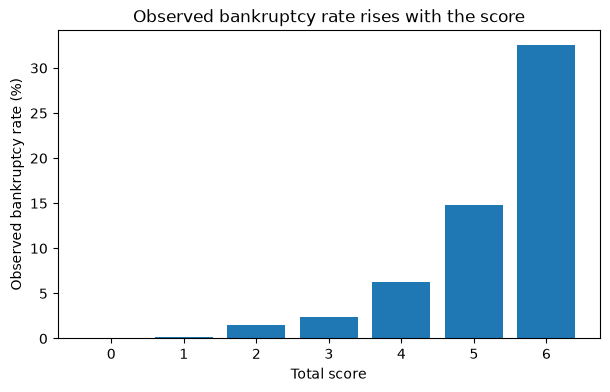

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(
    score_risk.index.astype(str),
    score_risk['bankruptcy_rate_%']
)
plt.xlabel('Total score')
plt.ylabel('Observed bankruptcy rate (%)')
plt.title('Observed bankruptcy rate rises with the score')
plt.show()


### Short exercise

1. Is the score monotonic with observed risk?
2. Where does risk begin to rise sharply?
3. Would you call score 4 a 6.25% probability? Why not?

The third question matters: the score orders risk, but it has not yet been calibrated into a probability.


### What to look for

Ideally, the observed bankruptcy rate should generally increase as the score increases.

If that happens, the six-point score provides a very simple interpretation:

> **More risk points → companies with similar scores experienced bankruptcy more often in the development data.**

But the score itself is **not yet a probability**. A score of 4 does not mean 40% bankruptcy risk. Translating scores into trustworthy probabilities is a separate problem that we will examine later.


## 8. What Does Hand-Calculable Simplicity Cost?

We have now compressed three continuous financial indicators into a **0–6 point score**.

That makes the model much easier to calculate and communicate, but discretizing continuous variables can lose information.

We therefore compare the scorecard with the three-feature logistic model using stratified cross-validation.

To avoid leakage, the scorecard thresholds are recalculated **inside each training fold** before scoring the validation fold.


In [13]:
from sklearn.metrics import roc_auc_score, average_precision_score


def learn_scorecard_thresholds(df):
    return {
        'profitability': {
            'high_risk': df['Net Income to Total Assets'].quantile(0.20),
            'moderate_risk': df['Net Income to Total Assets'].quantile(0.40),
        },
        'leverage': {
            'moderate_risk': df['Debt ratio %'].quantile(0.60),
            'high_risk': df['Debt ratio %'].quantile(0.80),
        },
        'working_capital': {
            'high_risk': df['Working Capital to Total Assets'].quantile(0.20),
            'moderate_risk': df['Working Capital to Total Assets'].quantile(0.40),
        },
    }


def apply_scorecard(df, t):
    profitability = np.select(
        [
            df['Net Income to Total Assets'] <= t['profitability']['high_risk'],
            df['Net Income to Total Assets'] <= t['profitability']['moderate_risk'],
        ],
        [2, 1],
        default=0,
    )

    leverage = np.select(
        [
            df['Debt ratio %'] >= t['leverage']['high_risk'],
            df['Debt ratio %'] >= t['leverage']['moderate_risk'],
        ],
        [2, 1],
        default=0,
    )

    working_capital = np.select(
        [
            df['Working Capital to Total Assets'] <= t['working_capital']['high_risk'],
            df['Working Capital to Total Assets'] <= t['working_capital']['moderate_risk'],
        ],
        [2, 1],
        default=0,
    )

    return profitability + leverage + working_capital


results = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(development_data, development_data['Bankrupt?']), 1):
    fold_train = development_data.iloc[train_idx]
    fold_valid = development_data.iloc[valid_idx]

    y_train = fold_train['Bankrupt?']
    y_valid = fold_valid['Bankrupt?']

    # Hand-calculable scorecard
    fold_thresholds = learn_scorecard_thresholds(fold_train)
    score = apply_scorecard(fold_valid, fold_thresholds)

    results.append({
        'fold': fold,
        'model': '0–6 scorecard',
        'ROC-AUC': roc_auc_score(y_valid, score),
        'PR-AUC': average_precision_score(y_valid, score),
    })

    # Three-feature logistic model
    logistic = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000)
    )

    logistic.fit(fold_train[small_features], y_train)
    probability = logistic.predict_proba(fold_valid[small_features])[:, 1]

    results.append({
        'fold': fold,
        'model': '3-feature logistic',
        'ROC-AUC': roc_auc_score(y_valid, probability),
        'PR-AUC': average_precision_score(y_valid, probability),
    })

scorecard_comparison = pd.DataFrame(results)

scorecard_comparison.groupby('model')[['ROC-AUC', 'PR-AUC']].agg(['mean', 'std']).round(3)


ROC-AUC        PR-AUC       
                      mean    std   mean    std
model                                          
0–6 scorecard        0.897  0.029  0.224  0.049
3-feature logistic   0.923  0.027  0.371  0.033

### What the result says

The hand-calculable scorecard is still a useful risk ranking, but it pays a measurable price for discretization:

- 3-feature logistic: ROC-AUC ≈ **0.923**, PR-AUC ≈ **0.371**
- 0–6 scorecard: ROC-AUC ≈ **0.897**, PR-AUC ≈ **0.224**

The larger drop in PR-AUC is especially important because bankruptcy is rare. Integer simplicity improves usability, but it removes predictive resolution.


### Interpretation

The scorecard deliberately throws away some information: exact financial values are replaced by a few ranges and integer points.

The comparison tells us the **price of that simplicity**.

If performance remains reasonably close, the scorecard may offer a useful trade-off: slightly less predictive resolution in exchange for much greater transparency and manual usability.

> The goal is not to prove that simpler is always better. The goal is to make the trade-off visible and measurable.


## 9. Hand-Built Scorecard vs Direct Integer Optimization



Our teaching scorecard is deliberately simple:



1. choose a small set of financial variables,

2. convert continuous values into interpretable conditions,

3. assign small integer points,

4. add the points to obtain a total risk score.



This makes the model easy to inspect and calculate by hand. However, the thresholds and point values were designed in separate steps rather than optimized jointly for prediction.



### RiskSLIM idea



**RiskSLIM (Risk-Supersparse Linear Integer Models)** directly learns a sparse scorecard with small integer coefficients.



A central objective is:



$$

V(\lambda)=\ell(\lambda)+C_0\|\lambda\|_0

$$



where:



- $\ell(\lambda)$ is empirical prediction loss,

- $\|\lambda\|_0$ is the number of non-zero coefficients,

- $C_0$ controls the penalty for complexity.



So simplicity becomes part of the **learning objective itself**, rather than only a manual simplification after fitting another model.



> Binary or thresholded indicators are especially convenient in scorecards because each condition can map cleanly to a small number of points.


### Why not optimize everything automatically here?

For this notebook, our goal is to understand the mechanics and trade-offs of an interpretable scorecard rather than depend on a specialized optimization solver.

Our hand-built score therefore serves as a transparent teaching model. RiskSLIM represents the more principled optimization-based extension of the same idea.

### Key distinction

| Approach | How simplicity is created |
|---|---|
| Traditional teaching scorecard | Choose variables, thresholds, and integer points explicitly |
| RiskSLIM-style model | Learn sparse integer coefficients directly through optimization |

The important lesson is not that one method is always superior. It is that **integer simplicity itself can be treated as part of the model-design objective** rather than only as a cosmetic step after modeling.


### Reflection

Suppose the optimized integer model achieved slightly better predictive performance but used twice as many conditions.

**Would that automatically make it the better decision tool?**

The answer depends on who must use the model, how often it is calculated, and how much complexity that setting can tolerate.


## 10. Good Ranking Is Not the Same as Good Probability Estimates



So far, we have mainly asked whether models can distinguish higher-risk companies from lower-risk companies.



But a different question matters when probabilities are used for decisions:



> If the model predicts about 10% bankruptcy probability for a group of companies, do roughly 10% of those companies actually experience bankruptcy?



This property is called **calibration**.



The 0–6 scorecard is an ordinal risk score, not a probability model. For the calibration lesson, we return to the **3-feature logistic model**, because it outputs probabilities directly.



A model can discriminate well while still producing probabilities that are systematically too high or too low.


### Development-set calibration check

We generate **out-of-fold probabilities** so that each company's probability comes from a model that was not trained on that company.

This lets us inspect calibration without touching the final test set.


In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

calibration_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

y_dev = development_data['Bankrupt?']

oof_probability = cross_val_predict(
    calibration_model,
    development_data[small_features],
    y_dev,
    cv=cv,
    method='predict_proba'
)[:, 1]

print('Observed bankruptcy rate:', round(y_dev.mean(), 4))
print('Mean predicted probability:', round(oof_probability.mean(), 4))
print('Brier score:', round(brier_score_loss(y_dev, oof_probability), 4))
print('Log loss:', round(log_loss(y_dev, oof_probability), 4))


Observed bankruptcy rate: 0.0323
Mean predicted probability: 0.0323
Brier score: 0.0258
Log loss: 0.102


### Reliability by probability group

Next, we divide the predictions into five equally sized groups and compare the **average predicted probability** with the **observed bankruptcy rate** in each group.


In [15]:
observed, predicted = calibration_curve(
    y_dev,
    oof_probability,
    n_bins=5,
    strategy='quantile'
)

calibration_table = pd.DataFrame({
    'Mean predicted probability': predicted,
    'Observed bankruptcy rate': observed,
})

calibration_table.round(4)


,Mean predicted probability,Observed bankruptcy rate
0,0.0019,0.0000
1,0.0054,0.0018
2,0.0114,0.0046
3,0.0236,0.0137
4,0.1194,0.1412


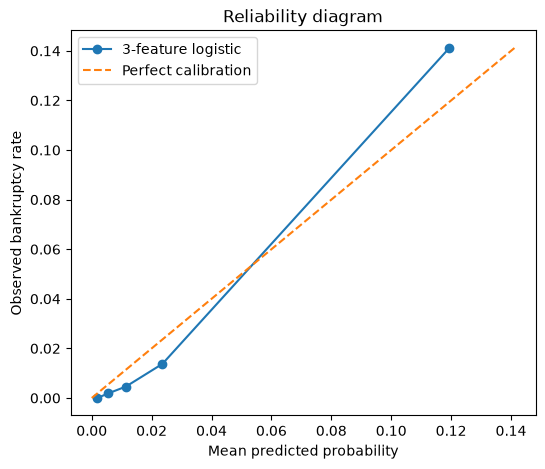

In [16]:
plt.figure(figsize=(6, 5))

plt.plot(
    calibration_table['Mean predicted probability'],
    calibration_table['Observed bankruptcy rate'],
    marker='o',
    label='3-feature logistic'
)

limit = max(
    calibration_table['Mean predicted probability'].max(),
    calibration_table['Observed bankruptcy rate'].max()
)

plt.plot([0, limit], [0, limit], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed bankruptcy rate')
plt.title('Reliability diagram')
plt.legend()
plt.show()


### Read the curve

Points **below** the diagonal indicate over-prediction; points **above** it indicate under-prediction.

Here, the middle probability groups are somewhat over-predicted, while the highest-risk group is slightly under-predicted. The pattern is informative, but each bin contains relatively few bankruptcy events, so avoid over-interpreting small differences.


### How to read this table

Perfect calibration would place predicted and observed rates close together.

For example, if a group receives an average predicted probability of **0.10**, we would expect approximately **10%** of that group to experience the event.

Differences between the two columns indicate **miscalibration**.

Two important ideas follow:

- **Discrimination:** Can the model rank higher-risk companies above lower-risk companies?
- **Calibration:** Can the numerical probabilities themselves be trusted?

A model can perform well on one and poorly on the other.


### A caution about probabilistic metrics



Bankruptcy occurs in only a small fraction of observations, so a numerically small Brier score does not automatically mean calibration is excellent.



Also, the **Brier score is an overall probability-accuracy measure**, not a pure measure of calibration. It reflects both calibration and how well predictions separate outcomes.



We therefore examine several pieces of evidence together:



- the reliability table / calibration curve,

- Brier score,

- log loss,

- event prevalence,

- and the stability of any recalibration method.


## 11. Should We Recalibrate the Model?

Calibration methods can adjust predicted probabilities after a model has been fitted.

We compare three versions:

- **Raw logistic probabilities**
- **Sigmoid calibration** — a smooth parametric adjustment
- **Isotonic calibration** — a more flexible non-parametric adjustment

To evaluate them fairly, we split the development data again into:

**model training → calibration → validation**

The final test set remains untouched.


In [17]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

model_train, temp = train_test_split(
    development_data,
    test_size=0.40,
    stratify=development_data['Bankrupt?'],
    random_state=42
)

calibration_data, validation_data = train_test_split(
    temp,
    test_size=0.50,
    stratify=temp['Bankrupt?'],
    random_state=42
)

base_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

base_model.fit(
    model_train[small_features],
    model_train['Bankrupt?']
)

sigmoid_model = CalibratedClassifierCV(
    FrozenEstimator(base_model),
    method='sigmoid'
)
_ = sigmoid_model.fit(
    calibration_data[small_features],
    calibration_data['Bankrupt?']
)

isotonic_model = CalibratedClassifierCV(
    FrozenEstimator(base_model),
    method='isotonic'
)
_ = isotonic_model.fit(
    calibration_data[small_features],
    calibration_data['Bankrupt?']
)

print('Bankrupt cases used for model training:', int(model_train['Bankrupt?'].sum()))
print('Bankrupt cases used for calibration:', int(calibration_data['Bankrupt?'].sum()))
print('Bankrupt cases used for validation:', int(validation_data['Bankrupt?'].sum()))


Bankrupt cases used for model training: 106
Bankrupt cases used for calibration: 35
Bankrupt cases used for validation: 35


### Compare discrimination and probability quality

Calibration should be evaluated using probability-sensitive measures such as **Brier score** and **log loss**, while ROC-AUC and PR-AUC help us see whether ranking ability changes.


In [18]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
)

y_valid = validation_data['Bankrupt?']

probabilities = {
    'Raw': base_model.predict_proba(validation_data[small_features])[:, 1],
    'Sigmoid': sigmoid_model.predict_proba(validation_data[small_features])[:, 1],
    'Isotonic': isotonic_model.predict_proba(validation_data[small_features])[:, 1],
}

calibration_results = []

for name, prob in probabilities.items():
    calibration_results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_valid, prob),
        'PR-AUC': average_precision_score(y_valid, prob),
        'Brier': brier_score_loss(y_valid, prob),
        'Log loss': log_loss(y_valid, prob),
    })

pd.DataFrame(calibration_results).set_index('Model').round(4)


,ROC-AUC,PR-AUC,Brier,Log loss
Model,,,,
Raw,0.8862,0.2987,0.0273,0.1149
Sigmoid,0.8862,0.2987,0.0263,0.1103
Isotonic,0.8826,0.2991,0.0270,0.1330


### Interpretation

Calibration is **not automatically an improvement**.

A calibration method may improve one probability metric while worsening another, especially when the event is rare and the calibration sample contains relatively few positive cases.

Sigmoid calibration often preserves ranking because it applies a monotonic transformation. A more flexible method such as isotonic regression can adapt more strongly, but it may also become unstable when data are limited.

> The lesson is not 'always calibrate.' The lesson is **diagnose, calibrate if needed, and validate the result**.


## 12. From Explanation to Recourse

A prediction answers:

> **What does the model think may happen?**

An explanation asks:

> **Why did the model assign this company a high score?**

Recourse asks something different:

> **What would need to change for the model's decision to change?**

To demonstrate this idea, we use the scorecard itself.

For illustration, suppose a score of **4 or more** triggers a high-risk screening flag.

> This threshold is used only to demonstrate counterfactual reasoning. It is not presented as an optimal or validated business decision threshold.


In [19]:
SCREENING_THRESHOLD = 4

development_score_details = bankruptcy_score(development_data)

screening_data = development_data[small_features + ['Bankrupt?']].copy()
screening_data = screening_data.join(development_score_details)

screening_data['high_risk_flag'] = (
    screening_data['total_score'] >= SCREENING_THRESHOLD
).astype(int)

screening_data[
    screening_data['high_risk_flag'] == 1
].head()


,Net Income to Total Assets,Debt ratio %,Working Capital to Total Assets,Bankrupt?,profitability_points,leverage_points,working_capital_points,total_score,high_risk_flag
2711,0.796118,0.202618,0.702370,0,1,2,2,5,1
6428,0.633674,0.209783,0.705679,0,2,2,2,6,1
3751,0.756296,0.069565,0.736228,0,2,0,2,4,1
314,0.802518,0.172174,0.746327,0,1,2,2,5,1
5489,0.741606,0.141004,0.780271,0,2,1,1,4,1


### Inspect one high-risk company

Because the score is additive, we can see exactly which financial conditions contributed points.


In [20]:
example = screening_data[
    screening_data['high_risk_flag'] == 1
].iloc[0]

example[
    [
        'Net Income to Total Assets',
        'profitability_points',
        'Debt ratio %',
        'leverage_points',
        'Working Capital to Total Assets',
        'working_capital_points',
        'total_score',
    ]
]


Net Income to Total Assets         0.796118
profitability_points               1.000000
Debt ratio %                       0.202618
leverage_points                    2.000000
Working Capital to Total Assets    0.702370
working_capital_points             2.000000
total_score                        5.000000
Name: 2711, dtype: float64

### A simple flipset

A **flipset** describes a small set of feature changes that would move the model from one decision to another.

For our scorecard, the question becomes:

> Which score components would need to lose enough points for the total score to fall below 4?


In [21]:
points_to_remove = int(example['total_score'] - (SCREENING_THRESHOLD - 1))

print('Current score:', int(example['total_score']))
print('Score needed to leave high-risk screen:', SCREENING_THRESHOLD - 1)
print('Minimum points that must be removed:', points_to_remove)

print('\nPossible score components:')
print('Profitability points:', int(example['profitability_points']))
print('Leverage points:', int(example['leverage_points']))
print('Working-capital points:', int(example['working_capital_points']))


Current score: 5
Score needed to leave high-risk screen: 3
Minimum points that must be removed: 2

Possible score components:
Profitability points: 1
Leverage points: 2
Working-capital points: 2


In [22]:
flip_options = []

# A single-feature flip is possible when moving one component to its
# 0-point range removes enough points to cross the screening threshold.
if example['profitability_points'] >= points_to_remove:
    flip_options.append({
        'Model-level change': f"Net Income / Total Assets > {thresholds['profitability']['moderate_risk']:.4f}",
        'Points removed': int(example['profitability_points']),
        'New score': int(example['total_score'] - example['profitability_points'])
    })

if example['leverage_points'] >= points_to_remove:
    flip_options.append({
        'Model-level change': f"Debt ratio % < {thresholds['leverage']['moderate_risk']:.4f}",
        'Points removed': int(example['leverage_points']),
        'New score': int(example['total_score'] - example['leverage_points'])
    })

if example['working_capital_points'] >= points_to_remove:
    flip_options.append({
        'Model-level change': f"Working Capital / Total Assets > {thresholds['working_capital']['moderate_risk']:.4f}",
        'Points removed': int(example['working_capital_points']),
        'New score': int(example['total_score'] - example['working_capital_points'])
    })

pd.DataFrame(flip_options)


,Model-level change,Points removed,New score
0,Debt ratio % < 0.1254,2,3
1,Working Capital / Total Assets > 0.7951,2,3


### Recourse exercise

The table gives **model-level flip options**, not business recommendations.

For each option, ask:

1. Is the underlying feature directly actionable?
2. What real action could plausibly change it?
3. What constraints or side effects are missing from the model?
4. What causal evidence would be needed before presenting it as advice?

This is the boundary between a counterfactual explanation and responsible recourse.


### But is that real-world recourse?



Not necessarily.



The scorecard can tell us which **model-input change** would move a company below the screening threshold. But a financial ratio is not a button a company can directly press.



For example, changing debt ratio may require debt repayment, equity changes, asset changes, restructuring, or other operational decisions. Those actions have costs, constraints, dependencies, and downstream effects that are not represented in this dataset.



This gives us an important distinction:



- **Model-level recourse:** what input changes would alter the model's output?

- **Real-world action:** what feasible intervention could actually produce that input change?



The first can be computed from the model. The second requires additional domain, feasibility, and causal knowledge.



> A counterfactual change explains model sensitivity. It is **not evidence that performing that change will causally prevent bankruptcy**.


### Reflection

Suppose the model says that lowering the debt ratio would remove the high-risk flag.

**What can we legitimately conclude?**

We can conclude that the model's prediction is sensitive to that feature and that a different value could change the model's decision.

We cannot conclude from this model alone that lowering the debt ratio will causally prevent bankruptcy.


## 13. Final Evaluation on the Untouched Test Set

Until this point, feature selection, scorecard construction, and model-design decisions were made using only the development data.

We now evaluate the final models on the **untouched test set**.

We compare three levels of complexity:

- **7-feature logistic model** — retains more financial information
- **3-feature logistic model** — represents three distinct financial concepts
- **0–6 scorecard** — converts those concepts into hand-calculable integer rules

The goal is not simply to find the highest metric. We want to make the **performance–interpretability trade-off** visible.


In [23]:
small_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

larger_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

small_model.fit(
    development_data[small_features],
    development_data['Bankrupt?']
)

larger_model.fit(
    development_data[larger_features],
    development_data['Bankrupt?']
)

y_test = test_data['Bankrupt?']

small_prob = small_model.predict_proba(
    test_data[small_features]
)[:, 1]

larger_prob = larger_model.predict_proba(
    test_data[larger_features]
)[:, 1]

test_score = bankruptcy_score(test_data)['total_score']


In [24]:
final_results = pd.DataFrame([
    {
        'Model': '7-feature logistic',
        'ROC-AUC': roc_auc_score(y_test, larger_prob),
        'PR-AUC': average_precision_score(y_test, larger_prob),
    },
    {
        'Model': '3-feature logistic',
        'ROC-AUC': roc_auc_score(y_test, small_prob),
        'PR-AUC': average_precision_score(y_test, small_prob),
    },
    {
        'Model': '0–6 scorecard',
        'ROC-AUC': roc_auc_score(y_test, test_score),
        'PR-AUC': average_precision_score(y_test, test_score),
    },
]).set_index('Model')

final_results.round(3)


,ROC-AUC,PR-AUC
Model,,
7-feature logistic,0.928,0.439
3-feature logistic,0.919,0.385
0–6 scorecard,0.899,0.237


### Interpreting the final comparison



On this held-out test set:



- **7-feature logistic:** ROC-AUC ≈ **0.928**, PR-AUC ≈ **0.439**

- **3-feature logistic:** ROC-AUC ≈ **0.919**, PR-AUC ≈ **0.385**

- **0–6 scorecard:** ROC-AUC ≈ **0.899**, PR-AUC ≈ **0.237**



The three-feature model retains much of the discrimination of the larger logistic model while using only three financial concepts. The hand-calculable scorecard remains useful for ranking, but the larger drop in PR-AUC shows that strong simplification loses meaningful resolution for this rare-event task.



That is the trade-off we wanted to make visible:



> **Interpretability is not free.** The relevant question is whether additional predictive performance is worth additional complexity for the intended decision setting.



Because the test set contains only **44 bankrupt companies**, these holdout metrics should not be treated as precise estimates of future performance.


## 14. What Did We Learn?



This case began with many financial indicators and a rare bankruptcy outcome. Rather than treating interpretability as something added after modeling, we made it part of model design.



### 1. Sparse models can preserve much of the useful signal



Many financial indicators contained overlapping information. Selecting distinct financial concepts produced a much smaller model while retaining substantial discrimination.



### 2. A scorecard makes model logic operational



Continuous financial measurements were converted into understandable conditions and integer points. This makes the model easy to inspect and calculate, but discretization also removes information.



### 3. Ranking and probability are different problems



A strong ROC-AUC does not guarantee trustworthy probability estimates. Calibration must be examined separately.



### 4. Calibration is not automatically beneficial



Recalibration methods must themselves be validated. Flexible methods can become unstable when positive examples are scarce.



### 5. Explanation is not the same as recourse



A model can identify feature changes that alter its output. That does not establish that those changes are feasible, desirable, or causally capable of preventing bankruptcy.



### Important limitations



- The dataset does not provide a usable company identifier or row-level date for company-grouped or chronological evaluation, so this notebook uses a stratified random holdout.

- The final test set contains only 44 bankrupt observations.

- Score thresholds are dataset-derived quantiles, not universal accounting standards.

- No external validation is performed.

- Counterfactual feature changes are model-level statements, not causal business prescriptions.



### Appropriate use



This model can support **early risk screening and model understanding**. It should not be used here as an automated bankruptcy determination, a causal explanation of bankruptcy, or a guaranteed prescription for preventing it.


## Final Reflection

> **What exactly are we trying to explain, to whom, and for what decision?**

A more accurate model is not automatically a better decision tool, and a more interpretable model is not automatically trustworthy. Predictive performance, interpretability, calibration, actionability, and limitations all need to be evaluated in context.
